<a href="https://colab.research.google.com/github/inesochoa/lisbon-ml-school/blob/ad-wip/exercise_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tutorial on unsupervised learning for anomaly detection
=============

ML for Physics @ LIP: https://indico.lip.pt/event/1909/

Author: Inês Ochoa

# Introduction

The ATLAS and CMS experiments at the LHC are exploring the vast proton-proton collision dataset in search for signals of beyond the Standard Model (BSM) phenomena that can help explain some of the open questions in fundamental physics.
Typically, searches for BSM are conducted in a fully-supervised approach: the final state for the signal hypothesis is clearly defined and the event selection and optimisation is performed towards that particular class of signal model. 

Given all the null results observed by the many BSM searches underway, experimentalists should consider whether the data could contain new physics that isn't being tested for. Therefore, an alternative approach that increases signal model independence is to frame BSM searches as an anomaly detection (AD) problem. Unsupervised learning is one possible way of doing AD, which will be exemplified here. In short, an unsupervised algorithm is trained to learn the known SM processes (in data or simulation, with different challenges in each case), and in that way being able to identify BSM events as anomalies, without having been trained on them.

We will explore different methods:
* Auto-encoders
* Variational-autoencoders
* optimal transport?

# Setting up libraries

In [146]:
import numpy as np
import h5py
import math
import os
import pathlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import matplotlib
#import ot
from tqdm import tqdm
%matplotlib inline
import itertools
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, mean_squared_error
import numpy.ma as ma

from sklearn.model_selection import train_test_split

## PyTorch
import torch
import torch.nn as nn
from torch.nn import functional as F
import torch.utils.data as data
import torch.optim as optim
import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint


In [2]:
# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

# useful for later
CHECKPOINT_PATH = "saved_models/" # define a directory for saving the checkpoints
os.makedirs(CHECKPOINT_PATH, exist_ok=True)
os.environ["TORCH_HOME"] = CHECKPOINT_PATH

os.makedirs(CHECKPOINT_PATH+"/AD-task", exist_ok=True)


Global seed set to 42


Device: cuda:0


In [3]:
import gc
torch.cuda.empty_cache()
gc.collect()

37

In [4]:
os.environ["DATAPATH"] = "ad_dataset/"
os.makedirs(os.environ["DATAPATH"], exist_ok=True) # change path to what you need

# The dataset
The dataset used in this exercise is provided by the [ADC2021](https://mpp-hep.github.io/ADC2021/) data challenge.

The training dataset consists of 13 M Standard Model events (our "background") and four different Beyond the Standard Model signals which we can use to benchmark the performance of the anomaly detection models. The signals are the following:
* A leptoquark (LQ) with mass 80 GeV decaying to a b-jet and a tau-lepton: $LQ\rightarrow b\tau$.
* A neutral scalar boson ($A$) with mass 50 GeV decaying to 4 leptons (via $Z$-bosons): $A\rightarrow 4\ell$.
* A scalar boson with mass 60 GeV decaying to two tau leptons: $h\rightarrow \tau \tau$
* A charged scalar boson with mass 60 GeV decaying to a tau lepton and a neutrino: $h^\pm \rightarrow \tau \nu$.

You can find more details of the generated processes in [this paper](https://arxiv.org/abs/2107.02157).

In [5]:
# Download the input data by uncommenting the following lines:

#! wget https://zenodo.org/records/5046428/files/background_for_training.h5?download=1 -O background.h5
#! mv background.h5 $DATAPATH
#! wget https://zenodo.org/records/7152590/files/Ato4l_lepFilter_13TeV_filtered.h5?download=1 -O Ato4l.h5
#! mv Ato4l.h5 $DATAPATH
#! wget https://zenodo.org/records/7152599/files/leptoquark_LOWMASS_lepFilter_13TeV_filtered.h5?download=1 -O LQ.h5
#! mv LQ.h5 $DATAPATH
#! wget https://zenodo.org/records/7152614/files/hToTauTau_13TeV_PU20_filtered.h5?download=1 -O hTauTau.h5
#! mv hTauTau.h5 $DATAPATH
#! wget https://zenodo.org/records/7152617/files/hChToTauNu_13TeV_PU20_filtered.h5?download=1 -O hTauNu.h5
#! mv hTauNu.h5 $DATAPATH

In [6]:
! ls $DATAPATH

Ato4l.h5       flat_background.h5  flat_LQ.h5  LQ.h5
background.h5  flat_hTauNu.h5	   hTauNu.h5   results_AE.h5
flat_Ato4l.h5  flat_hTauTau.h5	   hTauTau.h5  results_VAE.h5


In [7]:
bkgfile = os.environ["DATAPATH"] + '/background.h5'

signals = ["Ato4l", "LQ", "hTauTau", "hTauNu"]
sigfiles = [os.environ["DATAPATH"]+'/'+s+'.h5' for s in signals]

The background and signal files include information on MET (missing transverse energy), up to 4 electrons, up to 4 muons and up to 10 jets in each event. The dataset is already zero-padded (so not all events have 4 electrons or 4 muons, etc.). For each particle, the particle type index (1: MET, 2: electron, 3: muon, 4: jet) and their $p_T$,$\eta$,$\phi$ is saved.

Note that MET is an object with no $\eta$ information.

In [8]:
# open background file and confirm shape and contents
with h5py.File(bkgfile, 'r') as f:
  print(f['Particles'].shape)
  particle_feat = (f['Particles_Names'][:])
  print(particle_feat)
  print(f['Particles_Classes'][:])

(13451915, 19, 4)
[b'Pt' b'Eta' b'Phi' b'Class']
[b'MET_class_1' b'Four_Ele_class_2' b'Four_Mu_class_3' b'Ten_Jet_class_4']


In the following, we'll consider only the leading objects of each type, for simplicity.

In [9]:
# take leading objects for simplicity
MET_index = 0
Electron_index = 1#3
Muon_index = 5#15
Jet_index = 9#27

Now let's define the training, test and validation datasets:

*Skip this cell if you have already saved the files locally*

In [10]:
# read background data, shuffle events and do the train_test_split
NEVENTS = 800000
with h5py.File(bkgfile, 'r') as f:
  full_data = f['Particles'][:,:,:-1]
  #print("full data", full_data.shape)
  np.random.shuffle(full_data)
  
  selector = [x for x in [MET_index,Electron_index,Muon_index,Jet_index]]
  full_data = full_data[:NEVENTS,selector,:]
  print(full_data.shape)

  X_train, X_test = train_test_split(full_data, test_size=0.2, shuffle=True)
  X_train, X_val = train_test_split(X_train, test_size=0.2)

  # flatten the data (good enough for the models we'll use)
  # note that this means we're reducing our data to 3 features (pt,eta,phi) and removing the particle index information
  # 19 x 3 = 57; actually, let's keep leading objects only 4 x 3 -> 12
  X_train = X_train.reshape(X_train.shape[0], 12)
  X_test = X_test.reshape(X_test.shape[0], 12)
  X_val = X_val.reshape(X_val.shape[0], 12)

  with h5py.File(os.environ["DATAPATH"] + '/flat_background.h5', 'w') as h5f:
        h5f.create_dataset('X_train', data = X_train)
        h5f.create_dataset('X_test', data = X_test)
        h5f.create_dataset('X_val', data = X_val)

# do the same for signals:
for i,name in enumerate(signals):
  with h5py.File(sigfiles[i], 'r') as f:
    full_signal = f['Particles'][:,:,:-1]
    full_signal = full_signal[:,selector,:]
    full_signal = full_signal.reshape(full_signal.shape[0], 12)
    with h5py.File(os.environ["DATAPATH"] + '/flat_'+name+'.h5', 'w') as h:
      h.create_dataset('Data', data = full_signal)

(800000, 4, 3)


In [11]:
! ls $DATAPATH

Ato4l.h5       flat_background.h5  flat_LQ.h5  LQ.h5
background.h5  flat_hTauNu.h5	   hTauNu.h5   results_AE.h5
flat_Ato4l.h5  flat_hTauTau.h5	   hTauTau.h5  results_VAE.h5


In [12]:
# open flat background file and confirm shape
f = h5py.File(os.environ["DATAPATH"] + '/flat_background.h5', 'r')
X_test = f['X_test']
print(X_test.shape)
X_train = f['X_train']
print(X_train.shape)
X_val = f['X_val']
print(X_val.shape)
#f.close()

(160000, 12)
(512000, 12)
(128000, 12)


## Plotting the data

In [13]:
# make plots of objects features in background sample vs signals
particles = ["MET","Leading Electron","Leading Muon","Leading Jet"]
leading_indices = [0, 3, 6, 9]
# some binning info
var_names = [r'$p_T$ [GeV]',r'$\eta$', r'$\phi$']
binning = [np.linspace(0,1000,50), np.linspace(-4,4,50), np.linspace(-4,4,50)]
# for later
std_binning = [np.linspace(-20,20,50), np.linspace(-5,5,50), np.linspace(-5,5,50)]

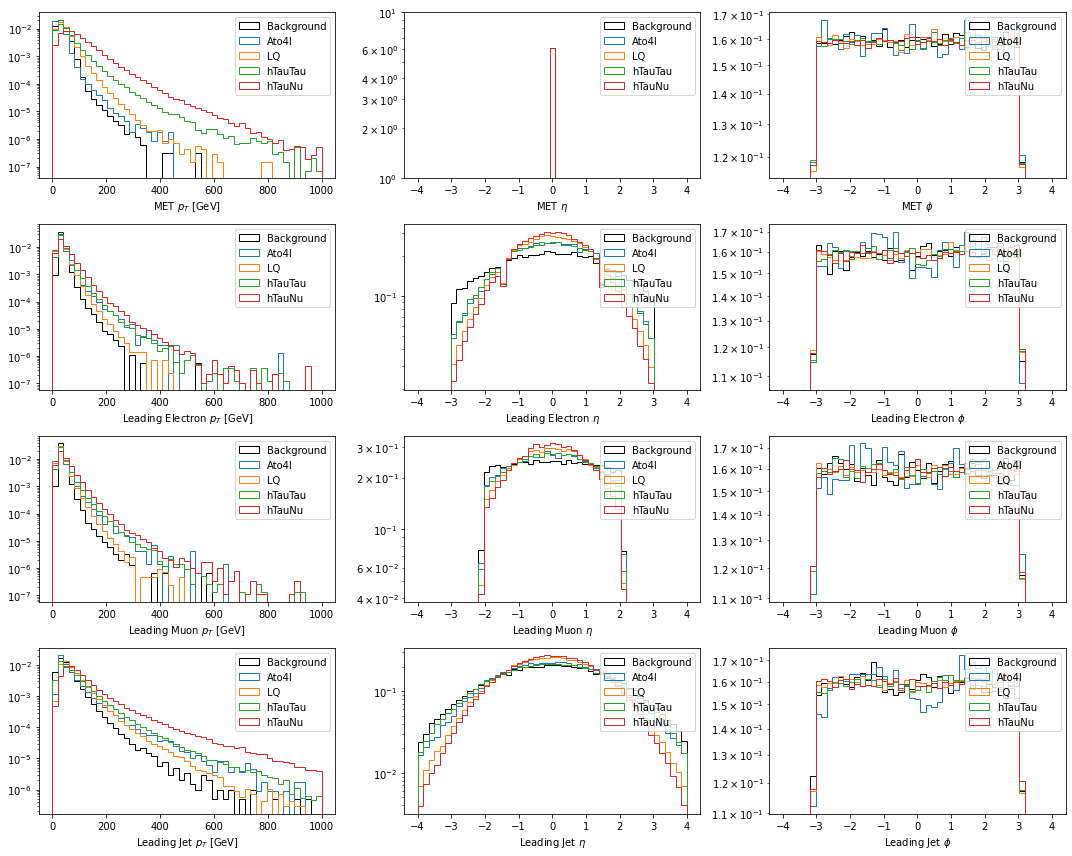

In [14]:
fig, axes = plt.subplots(4,3,figsize=(15,12))

for p,particle_type in enumerate(particles):
  # open flat background and plot
  with h5py.File(os.environ["DATAPATH"] + '/flat_background.h5', 'r') as f:
    mask = f['X_test'][:,leading_indices[p]] == 0
    for feat in range(3): # pt,eta,phi
      axes[p,feat].hist(f['X_test'][:,leading_indices[p]+feat][~mask],bins=binning[feat],label="Background",histtype='step',color="black",density=True)
      axes[p,feat].set_yscale("log")

  # now add signal distributions
  for s,name in enumerate(signals):
    with h5py.File(os.environ["DATAPATH"] + '/flat_'+name+'.h5', 'r') as f:
      mask = f['Data'][:,leading_indices[p]] == 0
      for feat in range(3): # pt,eta,phi
        axes[p,feat].hist(f['Data'][:,leading_indices[p]+feat][~mask],bins=binning[feat],label=name,histtype='step',density=True)
        axes[p,feat].set_yscale("log")
        axes[p,feat].set_xlabel(particles[p]+" "+var_names[feat])
        axes[p,feat].legend()
plt.tight_layout()
plt.show()

## Shortcut start

In [15]:
# open flat background file and confirm shape
f = h5py.File(os.environ["DATAPATH"] + '/flat_background.h5', 'r')
X_test = f['X_test']
X_train = f['X_train']
X_val = f['X_val']

## Pre-processing

Let's run pre-processing for the variables log(pt),eta,phi

In [16]:
from sklearn.preprocessing import StandardScaler

scl = StandardScaler()
scl = scl.fit(X_train)
X_train_std = scl.transform(X_train)
X_val_std = scl.transform(X_val)
X_test_std = scl.transform(X_test)

In [17]:
# Dataloaders!
batch_size = 2048
train_dl = data.DataLoader(X_train_std, batch_size=batch_size, shuffle=True, drop_last=True, pin_memory=True,num_workers=4)
val_dl   = data.DataLoader(X_val_std, batch_size=batch_size,num_workers=4)
test_dl  = data.DataLoader(X_test_std, batch_size=batch_size)

# Methods

## Auto-encoders

Auto-encoders (AE) are perhaps the most popular models for anomaly detection. Their task is to read input data and learn to output the same data. 

One of the components of AEs is the _encoder_, a series of hidden layers which map the input data to the latent space $z=f(x)$. Another component is the _decoder_ network, which then attempts to reconstruct the original input from the encoded representation, $x^\prime=g(z)$. The loss function can be any function of the form $g(f(x))$ with a mininum at $y=x$. A common choice is the Mean Squared Error (MSE): $\mathcal{L} = |y-x|^2$.

*TODO* add figure

Let's build an autoencoder with a 2 layer encoder + 2 layer decoder, for a given latent space dimension:

In [18]:
class AutoEncoder(nn.Module):
  def __init__(self, input_dimension, latent_dimension):
    super().__init__()
    self.input_dimension = input_dimension
    self.latent_dimension = latent_dimension

    self.encoder = nn.Sequential(
      nn.Linear(self.input_dimension, 8, bias=False),
      nn.ReLU(),
      nn.Linear(8, 6, bias=False),
      nn.ReLU(),
      nn.Linear(6, self.latent_dimension, bias=False))
    self.decoder = nn.Sequential(
      nn.Linear(self.latent_dimension, 6, bias=False),
      nn.ReLU(),
      nn.Linear(6, 8, bias=False),
      nn.ReLU(),
      nn.Linear(8, self.input_dimension, bias=False))

  def forward(self, x):
    x = self.encoder(x)
    x = self.decoder(x)
    return x

In [43]:
input_dimension = 12
latent_dimension = 3

autoencoder = AutoEncoder(input_dimension,latent_dimension)
autoencoder.to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-4)

Now that the model is defined, let's compile and train it.

The loss function we'll use is the mean squared error between the input ($X$) and output / reconstructed input ($X^\prime$):



In [44]:
def train_it(num_epochs, model, optimizer, train_dl, val_dl):
    
    log_dict = {'val_loss_per_epoch': [],
                'train_loss_per_epoch': []}
    
    loss_fn = F.mse_loss

    for epoch in range(num_epochs):
        val_losses = []
        train_losses = []

        model.train()
        for batch_idx, features_in in enumerate(train_dl):
            # forward
            features_in = features_in.to(device)
            features_in = features_in.float()
            features_out = model(features_in)
            # loss
            loss = loss_fn(features_out, features_in)

            # clear and backpropagate
            optimizer.zero_grad()
            loss.backward()
            train_losses.append(loss.item())

            # parameter update
            optimizer.step()
            
        model.eval()
        with torch.set_grad_enabled(False):  # save memory during inference
            for batch_idx, features_in in enumerate(val_dl):
                features_in = features_in.to(device)
                features_in = features_in.float()
                features_out = model(features_in)
                val_loss = loss_fn(features_out,features_in)
                val_losses.append(val_loss.item())
        
        epoch_val_loss = np.average(val_losses)
        epoch_train_loss = np.average(train_losses)
        
        print('Epoch: ', epoch, '| train loss: %.4f | val loss: %.4f'% (epoch_train_loss,epoch_val_loss))

        log_dict['val_loss_per_epoch'].append(epoch_val_loss)
        log_dict['train_loss_per_epoch'].append(epoch_train_loss)


    return log_dict

### Train

In [45]:
history = train_it(500, autoencoder, optimizer, train_dl, val_dl)

Epoch:  0 | train loss: 0.9159 | val loss: 0.9145
Epoch:  1 | train loss: 0.9105 | val loss: 0.9042
Epoch:  2 | train loss: 0.8914 | val loss: 0.8758
Epoch:  3 | train loss: 0.8631 | val loss: 0.8501
Epoch:  4 | train loss: 0.8351 | val loss: 0.8139
Epoch:  5 | train loss: 0.7917 | val loss: 0.7682
Epoch:  6 | train loss: 0.7508 | val loss: 0.7330
Epoch:  7 | train loss: 0.7199 | val loss: 0.7048
Epoch:  8 | train loss: 0.6909 | val loss: 0.6756
Epoch:  9 | train loss: 0.6638 | val loss: 0.6513
Epoch:  10 | train loss: 0.6427 | val loss: 0.6332
Epoch:  11 | train loss: 0.6269 | val loss: 0.6192
Epoch:  12 | train loss: 0.6143 | val loss: 0.6077
Epoch:  13 | train loss: 0.6036 | val loss: 0.5976
Epoch:  14 | train loss: 0.5940 | val loss: 0.5885
Epoch:  15 | train loss: 0.5851 | val loss: 0.5798
Epoch:  16 | train loss: 0.5766 | val loss: 0.5713
Epoch:  17 | train loss: 0.5682 | val loss: 0.5628
Epoch:  18 | train loss: 0.5598 | val loss: 0.5545
Epoch:  19 | train loss: 0.5515 | val los

Note: one should add early stopping + checkpoints for saving the best model, rather than just running for a fixed number of epochs and saving the last.

Let's look at the training & validation loss history:

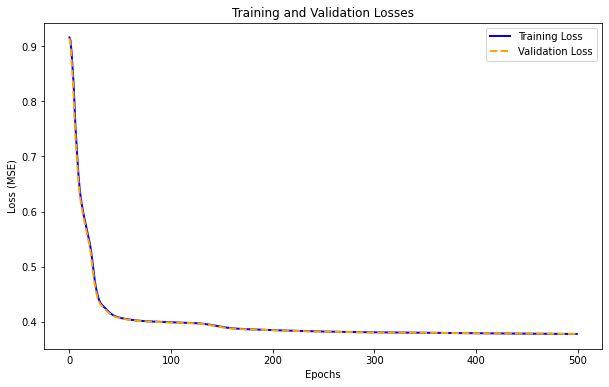

In [47]:
training_loss = history['train_loss_per_epoch']
validation_loss = history['val_loss_per_epoch']

# Plot training vs validation loss
plt.figure(figsize=(10, 6))
plt.plot(training_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(validation_loss, label='Validation Loss', color='orange', linestyle='dashed', linewidth=2)

# Add labels, legend, and title
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Losses')
plt.legend()
# Display the plot
plt.show()

In [48]:
torch.save(autoencoder.state_dict(), CHECKPOINT_PATH+"/AD-task/autoencoder_model.ckpt")


### Evaluate

Using this trained autoencoder, let's "run the reconstruction" on a different background sample as well as on our BSM signals.

In [49]:
# optional: reload saved model if you're starting from here
autoencoder.load_state_dict(torch.load(CHECKPOINT_PATH+"/AD-task/autoencoder_model.ckpt"))
autoencoder.eval()

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=12, out_features=8, bias=False)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=6, bias=False)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=3, bias=False)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=6, bias=False)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=8, bias=False)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=12, bias=False)
  )
)

In [183]:
bkg_prediction = autoencoder.forward(torch.tensor(X_test_std,dtype=torch.float).to(device))
bkg_prediction = bkg_prediction.clone().detach().cpu().numpy()

In [184]:
# read in the signal data - standardized it and save it
signal_data_std = []
for i, name in enumerate(signals):
    with h5py.File(os.environ["DATAPATH"] + '/flat_'+name+'.h5', 'r') as f:
        test_data = np.array(f['Data'])
        std_test_data = scl.transform(test_data)
        signal_data_std.append(std_test_data)

In [196]:
signal_predictions = []
# signals
for i, name in enumerate(signals):
  print(name)
  pred = autoencoder.forward(torch.tensor(signal_data_std[i],dtype=torch.float).to(device))
  pred = pred.clone().detach().cpu().numpy()
  signal_predictions.append(pred)

Ato4l
LQ
hTauTau
hTauNu


In [198]:
# Let's quickly save these:
with h5py.File(os.environ["DATAPATH"] + "/results_AE.h5", 'w') as file:
    file.create_dataset('BKG_input', data=X_test_std)
    file.create_dataset('BKG_predicted', data = bkg_prediction)
    for i, sig in enumerate(signal_predictions):
      file.create_dataset('%s_input'%signals[i], data=signal_data_std[i])
      file.create_dataset('%s_predicted'%signals[i], data=sig)
print("Results saved.")

Results saved.


In other words, we're evaluating our trained model on a new set of samples and getting out a dimension-12 vector per event, which are our reconstructed input features.

We can see how well our model did by comparing input and output features:

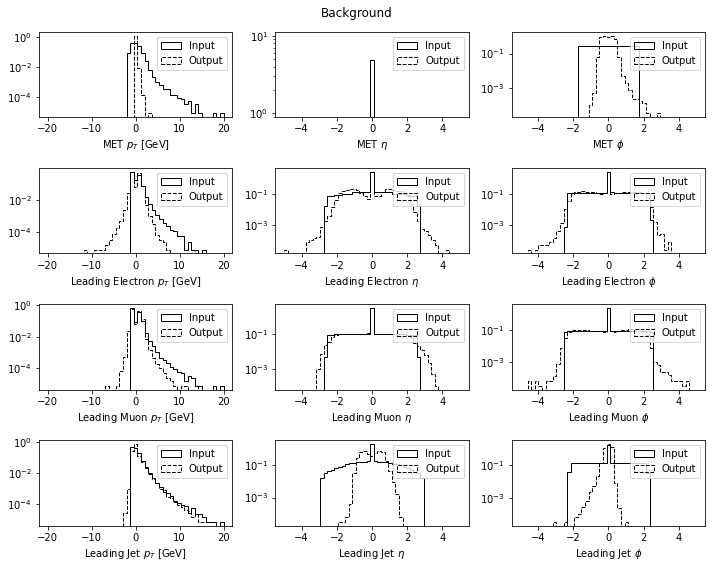

In [199]:
# first for the background
fig, axes = plt.subplots(4,3,figsize=(10,8))

for p,particle_type in enumerate(particles):
  # open flat background and plot
  with h5py.File(os.environ["DATAPATH"] + '/results_AE.h5', 'r') as f:
    for feat in range(3): # pt,eta,phi
      axes[p,feat].hist(f['BKG_input'][:,leading_indices[p]+feat],bins=std_binning[feat],label="Input",histtype='step',color="black",density=True)
      axes[p,feat].hist(f['BKG_predicted'][:,leading_indices[p]+feat],bins=std_binning[feat],label="Output",histtype='step',linestyle="dashed",color="black",density=True)
      axes[p,feat].set_yscale("log")
      axes[p,feat].set_xlabel(particles[p]+" "+var_names[feat])
      axes[p,feat].legend()
plt.suptitle("Background")
plt.tight_layout()
plt.show()

Clearly the AE does an ok job at reconstructed the $p_T$ but not so much the angular variables.

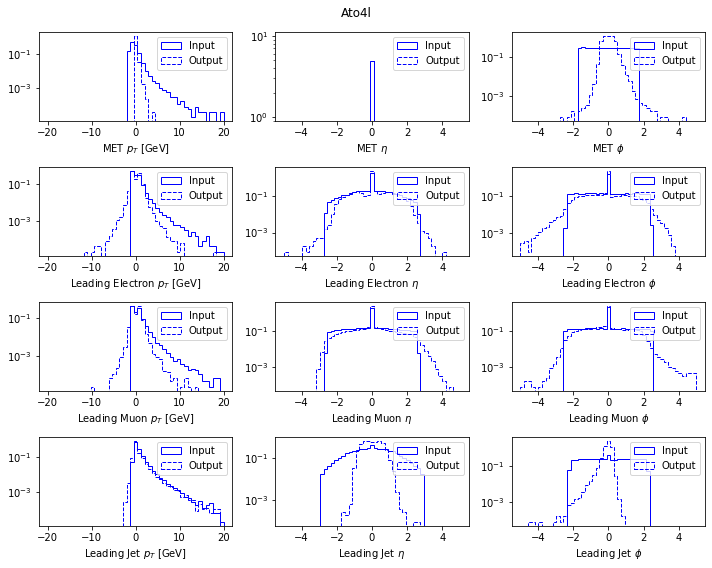

In [200]:
# now for one of the signals
fig, axes = plt.subplots(4,3,figsize=(10,8))

signal_choice = "Ato4l"
for p,particle_type in enumerate(particles):
  # open flat background and plot
  with h5py.File(os.environ["DATAPATH"] + '/results_AE.h5', 'r') as f:
    for feat in range(3): # pt,eta,phi
      axes[p,feat].hist(f['%s_input'%signal_choice][:,leading_indices[p]+feat],bins=std_binning[feat],label="Input",histtype='step',color="blue",density=True)
      axes[p,feat].hist(f['%s_predicted'%signal_choice][:,leading_indices[p]+feat],bins=std_binning[feat],label="Output",histtype='step',linestyle="dashed",color="blue",density=True)
      axes[p,feat].set_yscale("log")
      axes[p,feat].set_xlabel(particles[p]+" "+var_names[feat])
      axes[p,feat].legend()
plt.suptitle(signal_choice)
plt.tight_layout()
plt.show()

The MSE which defines the loss is also a good 1D metric to quantify the agreement between input and output:

In [201]:
def mse_loss_func(in_f, out_f):
    # I want MSE per event
    sqrdiff = np.square(np.subtract(in_f, out_f))
    return np.mean(sqrdiff,axis=1)

In [203]:
# compute loss value (true, predicted)
total_loss = []
# bkg
total_loss.append(mse_loss_func(X_test_std, bkg_prediction))
# signals
for i,sig_name in enumerate(signals):
    print(sig_name)
    total_loss.append(mse_loss_func(signal_data_std[i], signal_predictions[i]))

Ato4l
LQ
hTauTau
hTauNu


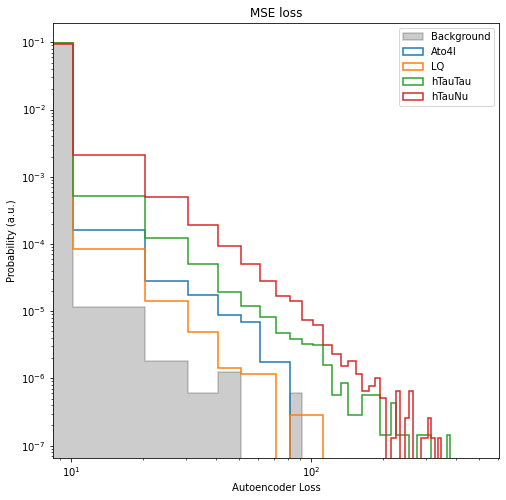

In [217]:
mse_binning = np.linspace(0,500,50)
plt.figure(figsize=(8,8))
#bkg
plt.hist(total_loss[0], bins=mse_binning, label="Background", color="black", density = True, histtype='step', fill=True, alpha=0.2, linewidth=1.5)
#signals
for i, label in enumerate(signals):
    plt.hist(total_loss[i+1], bins=mse_binning, label=label, density = True, histtype='step', fill=False, linewidth=1.5)
plt.yscale('log')
plt.xlabel("Autoencoder Loss")
plt.ylabel("Probability (a.u.)")
plt.title('MSE loss')
plt.legend(loc='best')
plt.xscale("log")
plt.show()

### ROC

We can turn this into a ROC curve now.

In [239]:
# make a general enough function first

def make_roc(loss_discrim,title): # assume first element is for background, remaining are signals
    
        et_background = np.zeros(loss_discrim[0].shape[0])

    save_rocs = []

    plt.figure(figsize=(8,6))
    for i, label in enumerate(signals):
        
        trueVal = np.concatenate((np.ones(loss_discrim[i+1].shape[0]), target_background)) # anomaly=1, bkg=0
        predVal_loss = np.concatenate((loss_discrim[i+1], loss_discrim[0]))

        fpr_loss, tpr_loss, threshold_loss = roc_curve(trueVal, predVal_loss)

        auc_loss = auc(fpr_loss, tpr_loss)

        plt.plot(fpr_loss, tpr_loss, "-", label='%s (auc = %.1f%%)'%(label,auc_loss*100.), linewidth=1.5)

        plt.semilogx()
        plt.semilogy()
        plt.ylabel("True Positive Rate")
        plt.xlabel("False Positive Rate")
        plt.legend(loc='center right')

        plt.tight_layout()
        save_rocs.append((fpr_loss,tpr_loss))
    plt.plot(np.linspace(0, 1),np.linspace(0, 1), '--', color='0.75')
    #plt.axvline(0.00001, color='red', linestyle='dashed', linewidth=1) # threshold value for measuring anomaly detection efficiency
    plt.title(title)
    plt.show()
    return save_rocs

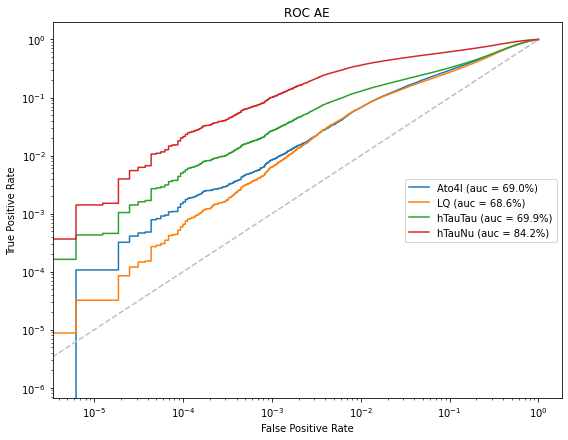

In [240]:
rocs_AE = make_roc(total_loss, "ROC AE")

## Variational auto-encoder

Variational auto-encoders (VAE) extend the vanilla AEs to perform Bayesian inference. VAEs assume that the observed data $x$ is generated by some latent random variable $z$ with a posterior distribution $p(z|x)$ which is intractable. The VAE is trained to learn an approximation to this function, $q(z|x)$.

In this case, the latent space maps data into a distribution rather than a single vector, e.g. a multivariate Gaussian of diagonal covariance. In the following, we implement an encoder that maps the input into two independent layers, one representing the means of the Gaussian distributions, the other representing their standard deviations in each dimension. 

The decoding step then performs a sampling step from this distribution in order to recover the input data. The training of the VAE through this stochastic step is possible via the reparameterization trick: considering that in our case $z$ is sampled from a Gaussian distribution, $z~\mathcal{N}(\mu,\sigma^2)$, the trick is to inject randomness via a variable $\epsilon$ such that $z=\mu+ \sigma \epsilon$, with $\epsilon~\mathcal{N}(0,1)$.

*TODO* add figure.

The VAE is a type of generative model: its ability to embed complex data into a low dimension manifold can be use to generate samples of higher dimensionality that approximate the probability densities of the input. 

In [110]:
class VAE(nn.Module):

    def __init__(self, input_shape, latent_dimension, device=device):
        super(VAE, self).__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_shape, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 16),
            nn.LeakyReLU(0.2),
            )
        
        # latent mean and variance 
        self.mean_layer = nn.Linear(16, latent_dimension)
        self.logvar_layer = nn.Linear(16, latent_dimension)
        
        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dimension, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, input_shape)
            )
        
    def encode(self, x):
        x = self.encoder(x)
        mean, logvar = self.mean_layer(x), self.logvar_layer(x)
        return mean, logvar

    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var)
        z = mean + var*epsilon  # reparameterization trick
        return z

    def decode(self, x):
        return self.decoder(x)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterization(mean, logvar)
        x_hat = self.decode(z)
        return x_hat, mean, logvar

In [111]:
input_shape = 12
latent_dimension = 3
vae = VAE(input_shape,latent_dimension).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)


In [112]:
def train_it_variational(num_epochs, model, optimizer, train_dl, val_dl):
    
    log_dict = {'val_loss_per_epoch': [],
                'train_loss_per_epoch': [],
                'val_reco_loss_per_epoch': [],
                'val_kl_loss_per_epoch': [],
                'train_reco_loss_per_epoch': [],
                'train_kl_loss_per_epoch': []}
    
    def loss_function(x, x_hat, mean, log_var):
        reco_loss = F.mse_loss(x_hat, x, reduction="mean")
        #reco_loss = torch.mean(F.mse_loss(x_hat, x, reduction="none"),dim=1)
        kld = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())
        loss = reco_loss + kld
        #print(reco_loss,kld)
        return loss, (reco_loss, kld)

    for epoch in range(num_epochs):
        val_losses = []
        train_losses = []

        train_reco_loss = []
        train_kl_loss = []

        val_reco_loss = []
        val_kl_loss = []
        model.train()
        for batch_idx, features_in in enumerate(train_dl):
            # forward
            features_in = features_in.float().to(device)
            xhat, mean, logvar = model(features_in)
            # loss
            loss, (reco_loss, kl_loss) = loss_function(features_in, xhat, mean, logvar)
            
            # clear and backpropagate
            optimizer.zero_grad()
            loss.backward()
            train_losses.append(loss.item())
            train_reco_loss.append(reco_loss.item())
            train_kl_loss.append(kl_loss.item())

            # parameter update
            optimizer.step()
            
        model.eval()
        with torch.set_grad_enabled(False):  # save memory during inference
            for batch_idx, features_in in enumerate(val_dl):
                features_in = features_in.float().to(device)
                xhat, mean, logvar = model(features_in) 
                val_loss, (reco_loss, kl_loss) = loss_function(features_in, xhat, mean, logvar)
                val_losses.append(val_loss.item())
                val_reco_loss.append(reco_loss.item())
                val_kl_loss.append(kl_loss.item())
        
        epoch_val_loss = np.average(val_losses)
        epoch_train_loss = np.average(train_losses)
        epoch_train_reco_loss = np.average(train_reco_loss)
        epoch_train_kl_loss = np.average(train_kl_loss)
        epoch_val_reco_loss = np.average(val_reco_loss)
        epoch_val_kl_loss = np.average(val_kl_loss)
        
        print('Epoch: ', epoch, '| train loss: %.3f | val loss: %.3f (reco=%.3f, kl=%.3f)'% (epoch_train_loss,epoch_val_loss,epoch_val_reco_loss,epoch_val_kl_loss))

        log_dict['val_loss_per_epoch'].append(epoch_val_loss)
        log_dict['val_kl_loss_per_epoch'].append(epoch_val_kl_loss)
        log_dict['val_reco_loss_per_epoch'].append(epoch_val_reco_loss)

        log_dict['train_loss_per_epoch'].append(epoch_train_loss)
        log_dict['train_reco_loss_per_epoch'].append(epoch_train_reco_loss)
        log_dict['train_kl_loss_per_epoch'].append(epoch_train_kl_loss)


    return log_dict

### Train

In [113]:
history = train_it_variational(50, vae, optimizer, train_dl, val_dl)

Epoch:  0 | train loss: 13.083 | val loss: 1.643 (reco=0.917, kl=0.726)
Epoch:  1 | train loss: 1.364 | val loss: 1.187 (reco=0.917, kl=0.270)
Epoch:  2 | train loss: 1.107 | val loss: 1.048 (reco=0.917, kl=0.131)
Epoch:  3 | train loss: 1.015 | val loss: 0.989 (reco=0.917, kl=0.073)
Epoch:  4 | train loss: 0.974 | val loss: 0.961 (reco=0.917, kl=0.044)
Epoch:  5 | train loss: 0.952 | val loss: 0.945 (reco=0.917, kl=0.028)
Epoch:  6 | train loss: 0.940 | val loss: 0.935 (reco=0.916, kl=0.019)
Epoch:  7 | train loss: 0.931 | val loss: 0.927 (reco=0.912, kl=0.015)
Epoch:  8 | train loss: 0.897 | val loss: 0.861 (reco=0.833, kl=0.027)
Epoch:  9 | train loss: 0.840 | val loss: 0.821 (reco=0.801, kl=0.020)
Epoch:  10 | train loss: 0.805 | val loss: 0.792 (reco=0.778, kl=0.014)
Epoch:  11 | train loss: 0.784 | val loss: 0.777 (reco=0.767, kl=0.010)
Epoch:  12 | train loss: 0.771 | val loss: 0.764 (reco=0.755, kl=0.009)
Epoch:  13 | train loss: 0.756 | val loss: 0.747 (reco=0.737, kl=0.010)
E

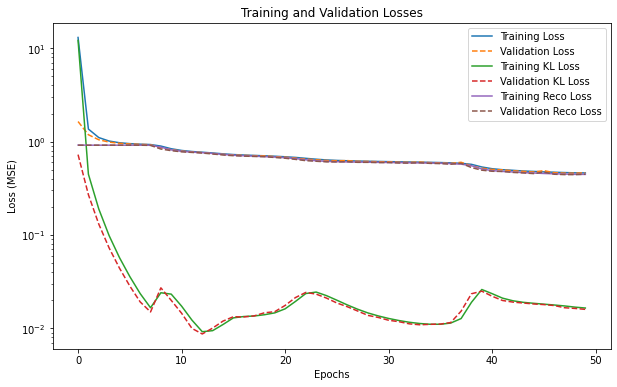

In [114]:
training_loss = history["train_loss_per_epoch"]
train_reco_loss = history["train_reco_loss_per_epoch"]
train_kl_loss = history["train_kl_loss_per_epoch"]
validation_loss = history["val_loss_per_epoch"]
val_reco_loss = history["val_reco_loss_per_epoch"]
val_kl_loss = history["val_kl_loss_per_epoch"]

# Plot training vs validation loss
plt.figure(figsize=(10, 6))
plt.plot(training_loss, label='Training Loss')#, color='blue', linewidth=2)
plt.plot(validation_loss, label='Validation Loss', linestyle='dashed')#, color='orange', linestyle='dashed', linewidth=2)

plt.plot(train_kl_loss, label='Training KL Loss')#, color='blue', linewidth=2)
plt.plot(val_kl_loss, label='Validation KL Loss', linestyle='dashed')#, color='orange', linestyle='dashed', linewidth=2)

plt.plot(train_reco_loss, label='Training Reco Loss')#, color='blue', linewidth=2)
plt.plot(val_reco_loss, label='Validation Reco Loss', linestyle='dashed')#, color='orange', linestyle='dashed', linewidth=2)

# Add labels, legend, and title
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Losses')
plt.legend()
plt.yscale("log")
# Display the plot
plt.show()

*TODO*: comment on loss behavior

In [64]:
# save it
torch.save(vae.state_dict(), CHECKPOINT_PATH+"/AD-task/vae_model.ckpt")

### Evaluate

In [65]:
# optional: reload saved model if you're starting from here
vae.load_state_dict(torch.load(CHECKPOINT_PATH+"/AD-task/vae_model.ckpt"))
vae.eval()

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=12, out_features=8, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=8, out_features=6, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
  )
  (mean_layer): Linear(in_features=6, out_features=3, bias=True)
  (logvar_layer): Linear(in_features=6, out_features=3, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=6, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=6, out_features=8, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=8, out_features=12, bias=True)
  )
)

In [115]:
bkg_prediction_vae = vae.forward(torch.tensor(X_test_std,dtype=torch.float).to(device))
bkg_xhat, bkg_mean, bkg_logvar = bkg_prediction_vae

In [116]:
bkg_xhat = bkg_xhat.detach().cpu().numpy()
bkg_mean = bkg_mean.detach().cpu().numpy()
bkg_logvar = bkg_logvar.detach().cpu().numpy()

In [205]:
# read in the signal data - standardized it and save it
signal_data = []
for i, name in enumerate(signals):
    with h5py.File(os.environ["DATAPATH"] + '/flat_'+name+'.h5', 'r') as f:
        test_data = np.array(f['Data'])
        std_test_data = scl.transform(test_data)
        signal_data.append(std_test_data)

signal_predictions_vae = []
signal_means = []
signal_logvar = []
# signals
for i, name in enumerate(signals):
  print(name)
  pred, mean, logvar = vae.forward(torch.tensor(signal_data[i],dtype=torch.float).to(device))
  pred = pred.clone().detach().cpu().numpy()
  mean = mean.clone().detach().cpu().numpy()
  logvar = logvar.clone().detach().cpu().numpy()
  signal_predictions_vae.append(pred)
  signal_means.append(mean)
  signal_logvar.append(logvar)

Ato4l
LQ
hTauTau
hTauNu


In [206]:
# Let's quickly save these:
with h5py.File(os.environ["DATAPATH"] + "/results_VAE.h5", 'w') as file:
    file.create_dataset('BKG_input', data=X_test_std)
    file.create_dataset('BKG_predicted', data = bkg_xhat)
    file.create_dataset('BKG_mu', data = bkg_mean)
    file.create_dataset('BKG_logvar', data = bkg_logvar)
    for i, sig in enumerate(signal_predictions):
      file.create_dataset('%s_predicted'%signals[i], data=sig)
      file.create_dataset('%s_mu'%signals[i], data=signal_means[i])
      file.create_dataset('%s_logvar'%signals[i], data=signal_logvar[i])
      file.create_dataset('%s_input'%signals[i], data=signal_data[i])
print("Results saved.")

Results saved.


We can make plots again:

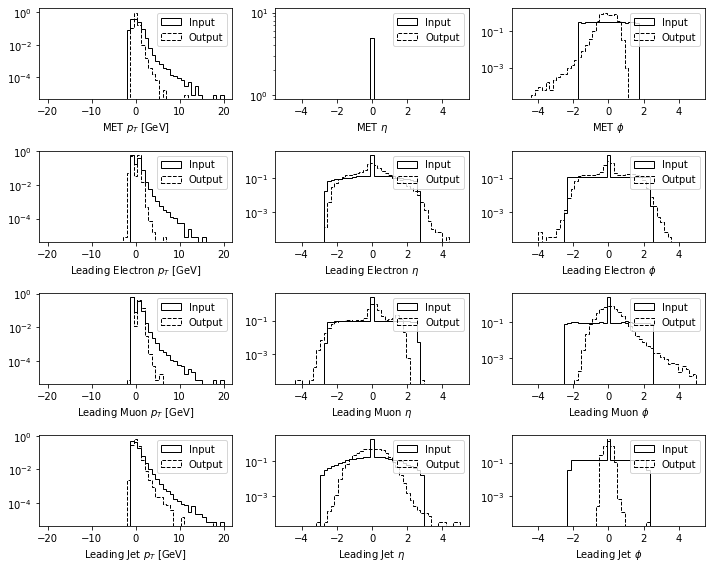

In [207]:
# first for the background
fig, axes = plt.subplots(4,3,figsize=(10,8))

for p,particle_type in enumerate(particles):
  # open flat background and plot
  with h5py.File(os.environ["DATAPATH"] + '/results_VAE.h5', 'r') as f:
    for feat in range(3): # pt,eta,phi
      axes[p,feat].hist(f["BKG_input"][:,leading_indices[p]+feat],bins=std_binning[feat],label="Input",histtype='step',color="black",density=True)
      axes[p,feat].hist(f["BKG_predicted"][:,leading_indices[p]+feat],bins=std_binning[feat],label="Output",histtype='step',linestyle="dashed",color="black",density=True)
      axes[p,feat].set_yscale("log")
      axes[p,feat].set_xlabel(particles[p]+" "+var_names[feat])
      axes[p,feat].legend()
plt.tight_layout()
plt.show()

Now we'll want to look at both MSE and the KL-losses as discriminants:

In [208]:
def kl_loss_func(z_mean, z_log_var):
    kl = 1. + z_log_var - np.square(z_mean) - np.exp(z_log_var)
    #print(kl)
    return -0.5 * np.mean(kl,axis=-1)

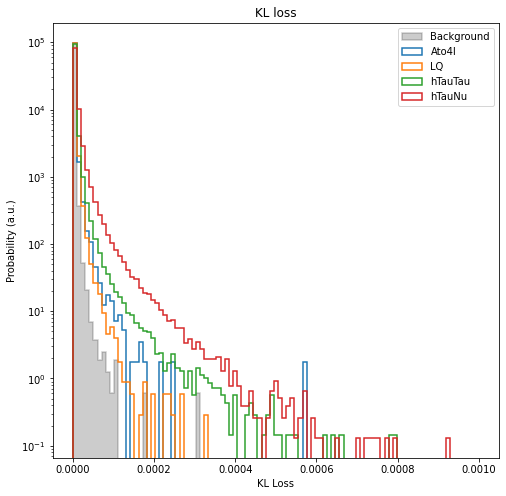

In [210]:
# compute loss value (true, predicted)
kl_loss = []
kl_loss.append(kl_loss_func(bkg_mean, bkg_logvar))
for i,sig_name in enumerate(signals):
    kl_loss.append(kl_loss_func(signal_means[i],signal_logvar[i]))

kl_binning = np.linspace(0,1e-3,100)
plt.figure(figsize=(8,8))
#bkg
plt.hist(kl_loss[0], bins=kl_binning, label="Background", color="black", density = True, histtype='step', fill=True, alpha=0.2, linewidth=1.5)
#signals
for i, label in enumerate(signals):
    plt.hist(kl_loss[i+1], bins=kl_binning, label=label, density = True, histtype='step', fill=False, linewidth=1.5)
plt.yscale('log')
plt.xlabel("KL Loss")
plt.ylabel("Probability (a.u.)")
plt.title('KL loss')
plt.legend(loc='best')
plt.show()    

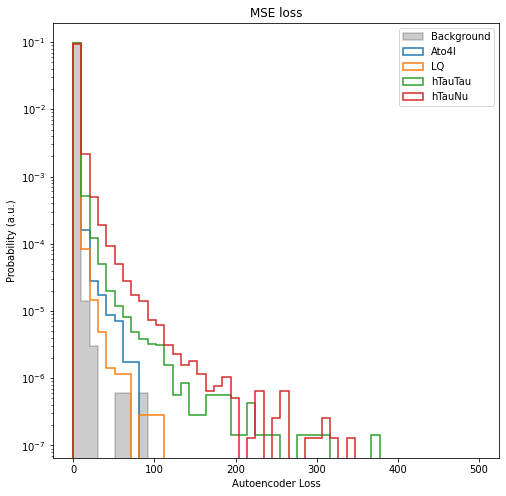

In [214]:
# compute loss value (true, predicted)
mse_loss = []
mse_loss.append(mse_loss_func(X_test_std, bkg_xhat))
for i,sig_name in enumerate(signals):
    mse_loss.append(mse_loss_func(signal_data[i], signal_predictions[i]))

mse_binning = np.linspace(0,500,50)
plt.figure(figsize=(8,8))
#bkg
plt.hist(mse_loss[0], bins=mse_binning, label="Background", color="black", density = True, histtype='step', fill=True, alpha=0.2, linewidth=1.5)
#signals
for i, label in enumerate(signals):
    plt.hist(mse_loss[i+1], bins=mse_binning, label=label, density = True, histtype='step', fill=False, linewidth=1.5)
plt.yscale('log')
plt.xlabel("Autoencoder Loss")
plt.ylabel("Probability (a.u.)")
plt.title('MSE loss')
plt.legend(loc='best')
plt.show()    

### ROC

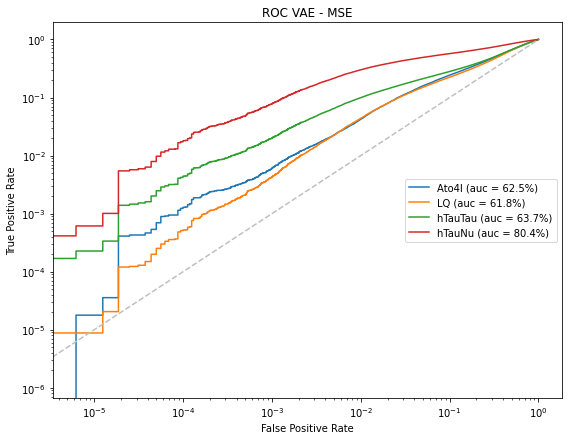

In [241]:
rocs_vae_mse = make_roc(mse_loss,title="ROC VAE - MSE")

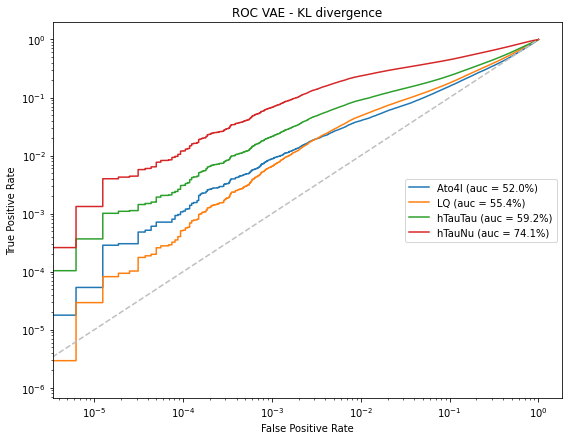

In [242]:
rocs_vae_kl = make_roc(kl_loss,title="ROC VAE - KL divergence")

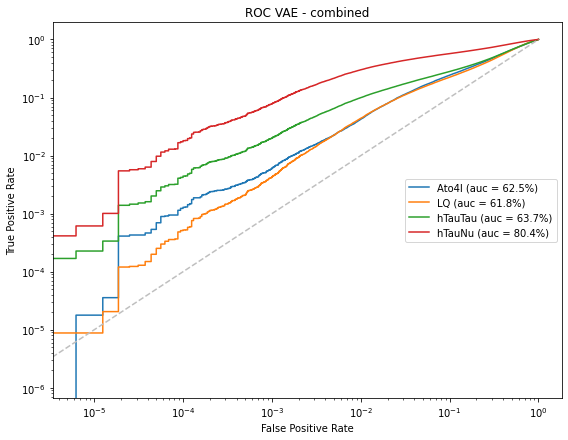

In [237]:
make_roc(mse_loss+100*kl_loss,title="ROC VAE - combined")

# ROC curve - compare methods

In [245]:
def compare_rocs(roc_methods,id):

    for i,label in enumerate(signals):
        
        plt.figure(figsize=(6,4))
        for method,result in enumerate(roc_methods):
            fpr_loss, tpr_loss = result[i]
            plt.plot(fpr_loss, tpr_loss, "-", label='%s (auc = %.1f%%)'%(id[method],auc_loss*100.), linewidth=1.5)
            plt.semilogx()
            plt.semilogy()
            plt.ylabel("True Positive Rate")
            plt.xlabel("False Positive Rate")
            plt.legend(loc='center right')
            plt.title(label)
            plt.tight_layout()

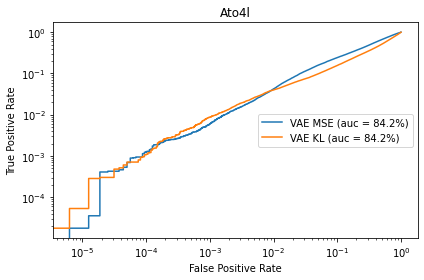

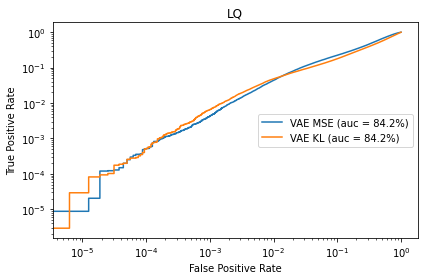

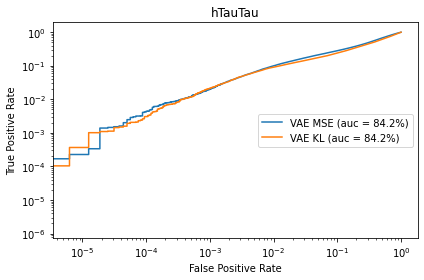

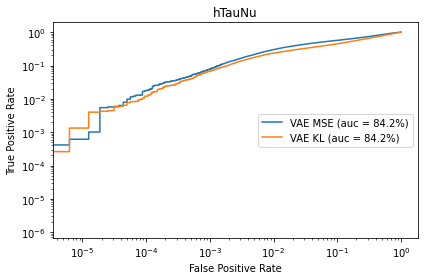

In [246]:
compare_rocs([rocs_vae_mse, rocs_vae_kl],["VAE MSE", "VAE KL"])

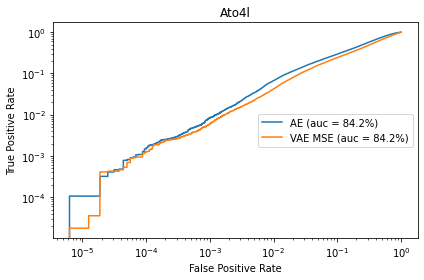

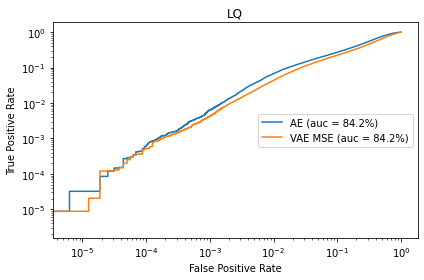

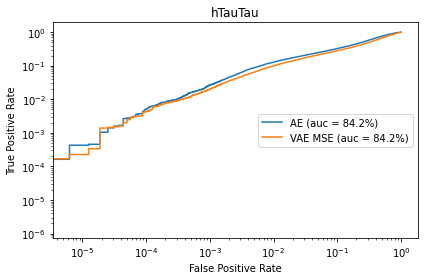

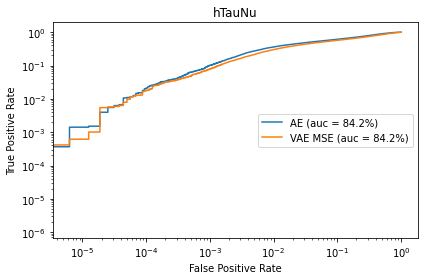

In [248]:
compare_rocs([rocs_AE, rocs_vae_mse],["AE", "VAE MSE"])

# Optimal transport

In [ ]:
dataDict = {}
dataDict['bkg'] = h5py.File(bkgfile, 'r')
for i,name in enumerate(signals): dataDict[name] = h5py.File(sigfiles[i], 'r')

In [ ]:
def randomDataSample(data, nEvents, random_state):
  """
  Generate a random sample of data by generating a 1D array of nEvents uniform
  random integers and returning the events corresponding to these integers.

  Inputs:
    data:          Total data array of shape (nTotal, 19, 3)
    nEvents:       Number of events to sample
    random_state:  The generator to use to generate the samples (for reproducibility)

  Outputs:
    Selected events; shape (nEvents, 19, 3)
  """
  #! Pretty slow in practice, make it faster later

  nTotal = data.shape[0]
  randomIntArray = random_state.integers(0,nTotal,nEvents)

  return data[randomIntArray, :, :]


In [ ]:
nEvents   = 1000
NREPEAT = 1
from numpy.random import Generator, PCG64
from tqdm.notebook import trange


#-- Check if file with datasamples already exists, if not sample and make one --#
sampledDataFile = os.environ['DATAPATH']+ '/sampledData_nEvents%s.npz'%(str(nEvents))

if os.path.exists(sampledDataFile):
  dummyDict = np.load(sampledDataFile, allow_pickle=True)

  # Unpack contents
  scoreDict = {}
  for key in dummyDict.files:
    scoreDict[key] = dummyDict[key].item()

else:
  # Dictionary structure to keep results (accounting for repeats to get statistical uncertainty)
  scoreDict = {}
  for irepeat in range(NREPEAT):
    name_repeat = 'repeat%d'%irepeat
    scoreDict[name_repeat] = {}

  # Generate 2 different samples of nEvents Background events
  random_state            = Generator(PCG64(123))
  for irepeat in tqdm(range(NREPEAT)):
    name_repeat = 'repeat%d'%irepeat
    scoreDict[name_repeat]['bkgEvents1'] = randomDataSample(dataDict['bkg']['Particles'][:, :, 0:3], nEvents, random_state)

  random_state            = Generator(PCG64(456))
  for irepeat in tqdm(range(NREPEAT)):
    name_repeat = 'repeat%d'%irepeat
    scoreDict[name_repeat]['bkgEvents2'] = randomDataSample(dataDict['bkg']['Particles'][:, :, 0:3], nEvents, random_state)

  # For each signal type, generate a sample of nEvents Signal events
  for sig in signals:
    random_state          = Generator(PCG64(123))
    for irepeat in tqdm(range(NREPEAT)):
      name_repeat = 'repeat%d'%irepeat
      scoreDict[name_repeat][sig]      = randomDataSample(dataDict[sig]['Particles'][:, :, 0:3], nEvents, random_state)

  # Save so we don't have to do this repeatedly...
  np.savez(sampledDataFile, **scoreDict)

In [ ]:
OTSCHEME = {}
OTSCHEME['normPT']       = False # pT should be unnormalized per event
OTSCHEME['balanced']     = True  # OT calculation is balanced
OTSCHEME['noZeroPad']    = False # zero padding is kept
OTSCHEME['individualOT'] = False # Don't calculate individual species OT
COSTSCHEME            = '3D'  # pT, eta, phi ground space
kwargs                = {}    # No other arguments to pass to function

In [ ]:
def checkSCHEMES(OTSCHEME, COSTSCHEME):
  """
  Auxiliary function to make calcOTDistance() a bit tidier while still checking that the schemes make sense

  See calcOTDistance for definition of OTSCHEME, COSTSCHEME
  """

  #-- Check that SCHEMES contain valid entries --#
  assert (COSTSCHEME in ['1DpT','2D', '3D']), "Error: Invalid COSTSCHEME"
  for key in OTSCHEME.keys():
    assert(OTSCHEME[key] in [True, False]), "Error: Invalid OTSCHEME"


  #-- Check that SCHEME combinations make sense --#

  if COSTSCHEME == '1DpT':

    # pT assumed to be unnormalized
    assert (OTSCHEME['normPT']==False), "Error: Invalid OTSCHEME['normPT'] for COSTSCHEME==%s"%(COSTSCHEME)

    # either balanced or unbalanced is fine
    # => nothing to check

    # if doing balanced then either removing or keeping zero padding is fine => nothing to check;
    # if doing unbalanced then zero padding should be removed
    if OTSCHEME['balanced']==False:
      assert (OTSCHEME['noZeroPad']==True), "Error: Invalid OTSCHEME['noZeroPad'] for COSTSCHEME==%s"%(COSTSCHEME)

    # check that we're not doing individual OT
    assert (OTSCHEME['individualOT']==False), "Error: Invalid OTSCHEME['individualOT'] for COSTSCHEME==%s"%(COSTSCHEME)

  elif COSTSCHEME == '2D':

    # either normalized or unnormalized pT is fine
    # => nothing to check

    # if pT is unnormalized we must be doing unbalanced
    # if pT is normalized we assume we're doing balanced
    if OTSCHEME['normPT']==False:
      assert (OTSCHEME['balanced']==False), "Error: Invalid OTSCHEME['balanced'] for COSTSCHEME==%s"%(COSTSCHEME)
    elif OTSCHEME['normPT']==True:
      assert (OTSCHEME['balanced']==True), "Error: Invalid OTSCHEME['balanced'] for COSTSCHEME==%s"%(COSTSCHEME)

    # check that we're not doing individual OT
    assert (OTSCHEME['individualOT']==False), "Error: Invalid OTSCHEME['individualOT'] for COSTSCHEME==%s"%(COSTSCHEME)

  elif COSTSCHEME == '3D':

    # either normalized or unnormalized pT is fine
    # => nothing to check

    # either balanced or unbalanced is fine
    # => nothing to check

    # either removing or keeping zero padding is fine
    # => nothing to check

    # if we're doing individual species we want balanced OT with unnormalized pT and zero padding intact
    if OTSCHEME['individualOT'] == True:
      assert (OTSCHEME['balanced']==True),   "Error: Invalid OTSCHEME['balanced'] for individualOT and COSTSCHEME==%s"%(COSTSCHEME)
      assert (OTSCHEME['normPT']==False),    "Error: Invalid OTSCHEME['normPT'] for individualOT and COSTSCHEME==%s"%(COSTSCHEME)
      assert (OTSCHEME['noZeroPad']==False), "Error: Invalid OTSCHEME['noZeroPad'] for individualOT and COSTSCHEME==%s"%(COSTSCHEME)


  # If all assert statements passed without issue then return True
  return True

In [ ]:
def calcOTDistance_non_square(xEvents, yEvents, OTSCHEME, COSTSCHEME, kwargs={}, Matrix = False):
  """
  Solve the optimal transport problem and find the 2-Wasserstein distance
  for a set of source events (xEvents) and target events (yEvents) for a
  given ground cost function.

  Inputs:
        xEvents:  Array of sample of x-type events; shape (N, 19, 3)
        yEvents:  Array of sample of y-type events; shape (M, 19, 3)
       OTSCHEME:  Determines what scheme will be used to calculate the OT distance.
                  Note the exact meaning varies somewhat depending on the choice of COSTSCHEME.
                  It's a dictionary of 3 booleans cooresponding to whether the PT is normalized,
                  whether the OT calculation is balanced, and whether the zero padding should be
                  removed. Namely,
                  OTSCHEME['normPT']      ==True:  Means that the pT should be normalized;
                                         ==False:  Means that the pT should be unnormalized
                  OTSCHEME['balanced']    ==True:  Means that the OT calculation should be balanced;
                                         ==False:  Means that the OT calculation should be unbalanced
                  OTSCHEME['noZeroPad']   ==True:  Means that the zero padding should be removed;
                                         ==False:  Means that the zero padding should be kept
                  OTSCHEME['individualOT']==True:  Means that the OT calculation is done on each species separately;
                                         ==False:  Means that the OT calculation is done ignoring species type
     COSTSCHEME:  Determines what scheme will be used to calculate the ground cost matrix. Options are:
                  - 1DpT: Ground space is pT only
                  - 2D:   Ground space is 2D (eta,phi); note mass is pT
                  - 3D:   Ground space is 3D (pT,eta,phi); note mass is uniform
         kwargs:  Dictionary containing keyword arguments for unbalanced OT calculation; default is an empty dictionary
         MATRIX:  Whether to return wXY as an (N,M) array or as a (N*M,) array

  Outputs

     wXY:  Matrix of the corresponding (squared) 2-Wasserstein distances, or list for default
  """

  #-- Sanity checks on inputs --#

  # Check schemes
  assert checkSCHEMES(OTSCHEME, COSTSCHEME)==True
  if OTSCHEME['balanced']==False:
    assert all([x in list(kwargs.keys()) for x in ['div', 'reg_m'] ])

  N = xEvents.shape[0]
  M = yEvents.shape[0]

  #-- Preliminaries --#
  # Create objects for outputs
  wXY = np.zeros(shape=(N,M))

  #-- Loop over pairs of events --#
  # We use itertools to make looping more efficient (i.e. do double for loops)
  dummyArr_1 = np.arange(N)
  dummyArr_2 = np.arange(M)
  wXY_list = []
  for (i, j) in itertools.product(dummyArr_1, dummyArr_2):
    #-- Get source and target data points--#
    # Remove zero-padding if specified
    if OTSCHEME['noZeroPad']==True:
      sMask = ~np.all(xEvents[i, :, :] == 0., axis=1) # Mask to remove zero rows
      tMask = ~np.all(yEvents[j, :, :] == 0., axis=1)

      xs = xEvents[i, :, :][sMask] # "source data points"
      xt = yEvents[j, :, :][tMask] # "target data points"
    else:
      xs = xEvents[i, :, :] # "source data points"
      xt = yEvents[j, :, :] # "target data points"

    #-- Get masses --#
    a,b = getMasses(xs, xt, OTSCHEME, COSTSCHEME)

    #-- Normalize pT coordinate if specified --#
    #! Might be more efficient to do this before getMasses() but then will need to change getMasses()
    if OTSCHEME['normPT']==True:
      totPTs, totPTt = xs[:,0].sum(), xt[:,0].sum()
      xs[:,0], xt[:,0] = xs[:,0]/totPTs, xt[:,0]/totPTt

    #-- Get cost function and append to list --#
    cxy = calcGroundCostMatrix(xs, xt, COSTSCHEME)

    #-- Calculate the unbalanced Wasserstein distance --#
    if OTSCHEME['balanced']==False:
      wXY[i,j] = ot.unbalanced.mm_unbalanced2(a, b, cxy, reg_m=kwargs['reg_m'], div=kwargs['div'])
      wXY_list.append(wXY[i,j])
    else:
      wXY[i,j] = ot.emd2(a, b, cxy)
      wXY_list.append(wXY[i,j])

  if Matrix == True:
    return wXY

  else:
    return np.asarray(wXY_list)

In [ ]:
def getMasses(xs, xt, OTSCHEME, COSTSCHEME):
  """
  Auxiliary function to get probability masses based on OTSCHEME and COSTSCHEME.
  There are 5 different options.
  """
  #-- Option 1:  m_i = 1/19 --#
  # There are 3 combinations that give this
  # They assume 1D or 3D, balanced, and zero-padded
  if (COSTSCHEME != '2D') and (OTSCHEME['balanced']==True) and (OTSCHEME['noZeroPad']==False) and (OTSCHEME['individualOT']==False):
    a = np.ones((19,)) / 19
    b = a

  #-- Option 2: m_i = 1, 1/4, or 1/10 depending on individual species type --#
  elif (COSTSCHEME != '2D') and (OTSCHEME['balanced']==True) and (OTSCHEME['noZeroPad']==False) and (OTSCHEME['individualOT']==True):
    nx, ny = xs.shape[0], xt.shape[0]
    a = np.ones((nx,)) / nx
    b = np.ones((ny,)) / ny

  #-- Option 3: m_i = 1/N, N=number of particles in the event --#
  # There are 3 combinations that give this
  # They assume 1D or 3D, balanced, and zero-padding removed
  elif (COSTSCHEME != '2D') and (OTSCHEME['balanced']==True) and (OTSCHEME['noZeroPad']==True):
    nx, ny = xs.shape[0], xt.shape[0]
    a = np.ones((nx,)) / nx
    b = np.ones((ny,)) / ny

  #-- Option 4: m_i = pT --#
  # There is only 1 combination that gives this
  elif (COSTSCHEME == '2D') and (OTSCHEME['normPT']==False):
    a = xs[:,0]
    b = xt[:,0]

  #-- Option 5: m_i = pT/sum(pT) --#
  # There is only 1 combination that gives this
  elif (COSTSCHEME == '2D') and (OTSCHEME['normPT']==True):
    totalpT_xs = np.sum(xs[:,0]) # Total pT in each x-event
    totalpT_xt = np.sum(xt[:,0]) # Total pT in each y-event

    a = np.ascontiguousarray(xs[:,0]/totalpT_xs) # POT error will result if not C-contiguous
    b = np.ascontiguousarray(xt[:,0]/totalpT_xt)

    # Assuming balanced OT, both total masses should be the same (up to some precision)
    # Using same precision considerations as POT library which is the default for np.testing.assert_almost_equal() (decimal=7)
    np.testing.assert_almost_equal(a.sum(0), b.sum(0,keepdims=True), err_msg='a and b vector must have the same sum')

  #-- Option 6: m_i = 1 --#
  else:
    nx, ny = xs.shape[0], xt.shape[0]
    a = np.ones((nx,))
    b = np.ones((ny,))

  return a, b

In [ ]:
def calcGroundCostMatrix(xs, xt, COSTSCHEME):
  """
  Calculate ground cost matrix between xs and xt

  Inputs:
             xs:  3D (pT, eta, phi) coordinates of nx source particles (shape=(nx,3));
                  nx = number of entries in xEvents
             xt:  3D (pT, eta, phi) coordinates of ny source particles (shape=(ny,3));
                  ny = number of entries in yEvents
     COSTSCHEME:  Determines what scheme will be used to calculate the ground cost matrix. Options are:
                  - 1DpT: Ground space is pT only
                  - 2D:   Ground space is 2D (eta,phi); note mass is pT
                  - 3D:   Ground space is 3D (pT,eta,phi); note mass is uniform

  Output:
     Returns matrix of pair-wise |x - y|^2 distances

  """
  if COSTSCHEME=='1DpT':
    return calcGroundCostMatrix_1DpT(xs, xt)
  elif COSTSCHEME=='2D':
    return calcGroundCostMatrix_2D(xs, xt)
  elif COSTSCHEME=='3D':
    return calcGroundCostMatrix_3D(xs, xt)
  else:
    print("Error: Invalid COSTSCHEME")
    return 0

def calcGroundCostMatrix_1DpT(xs, xt):
  """
  Auxiliary function, assumes ground space is pT only
  """
  deltaPT      = xs[:,0,None] - xt[:,0]
  return deltaPT**2


def calcGroundCostMatrix_2D(xs, xt):
  """
  Auxiliary function, assumes ground space is eta,phi.
  phi is 2pi modular which must be taken into account when computing the matrix of
  pair-wise |x - y|^2 distances
  """
  deltaEta     = xs[:,1,None] - xt[:,1]
  deltaPhi_raw = xs[:,2,None] - xt[:,2]
  deltaPhi     = np.pi - np.abs(np.pi - np.abs(deltaPhi_raw))
  return deltaEta**2 + deltaPhi**2

def calcGroundCostMatrix_3D(xs, xt):
  """
  Auxiliary function, assumes ground space is pT,eta,phi.
  phi is 2pi modular which must be taken into account when computing the matrix of
  pair-wise |x - y|^2 distances
  """
  deltaPT      = xs[:,0,None] - xt[:,0]
  deltaEta     = xs[:,1,None] - xt[:,1]
  deltaPhi_raw = xs[:,2,None] - xt[:,2]
  deltaPhi     = np.pi - np.abs(np.pi - np.abs(deltaPhi_raw))
  return deltaPT**2 + deltaEta**2 + deltaPhi**2

In [ ]:
def event_to_ensemble_dist(wXY, EVENT_TO_ENSEMBLE_TYPE, AXIS=0):
    """
    Calculate the event to ensemble distance.
    wXY should be an NxN matrix where wXY[i,j] is the OT distance between X[i] and Y[j]
    AXIS=0 assumes that X events are the reference population (i.e. ensemble)
    """
    if EVENT_TO_ENSEMBLE_TYPE=='MAX':
        return np.max(wXY, axis=AXIS)
    elif EVENT_TO_ENSEMBLE_TYPE=='MIN':
        return np.min(wXY, axis=AXIS)
    elif EVENT_TO_ENSEMBLE_TYPE=='MEAN':
        return np.mean(wXY, axis=AXIS)
    else:
        print("ERROR: Invalid EVENT_TO_ENSEMBLE_TYPE ",EVENT_TO_ENSEMBLE_TYPE)
        return 0

In [ ]:
EVENT_TO_ENSEMBLE_TYPE = 'MEAN' # 'MAX', 'MIN'
AXIS = 0
for irepeat in trange(NREPEAT):
  name_repeat = 'repeat%d'%irepeat
  print("Calculating ", name_repeat)

  #-- For background-to-background case --#
  # Note the 2-Wasserstein distance squared nEvents x nEvents matrix is returned i.e. wXY[i,j] = (W2(X[i], Y[j]))**2
  # We first turn this into an event-to-ensemble distance. Assuming that X comprise the ensemble population => AXIS=0
  # After this we take the square-root. The end result is an array with shape (nEvents,)
  wBB = calcOTDistance_non_square(scoreDict[name_repeat]['bkgEvents1'], scoreDict[name_repeat]['bkgEvents2'], OTSCHEME=OTSCHEME, COSTSCHEME=COSTSCHEME, kwargs=kwargs, Matrix=True)
  scoreDict[name_repeat]['wBB'] = np.sqrt(event_to_ensemble_dist(wBB, EVENT_TO_ENSEMBLE_TYPE=EVENT_TO_ENSEMBLE_TYPE, AXIS=AXIS))

  #-- For background-to-signal case --#
  for name in signals:
    name_w = 'wBS_'+name

    wBS = calcOTDistance_non_square(scoreDict[name_repeat]['bkgEvents1'], scoreDict[name_repeat][name], OTSCHEME=OTSCHEME, COSTSCHEME=COSTSCHEME, kwargs=kwargs, Matrix=True)
    scoreDict[name_repeat][name_w] = np.sqrt(event_to_ensemble_dist(wBS, EVENT_TO_ENSEMBLE_TYPE=EVENT_TO_ENSEMBLE_TYPE, AXIS=AXIS))

In [ ]:
scoreDict

In [ ]:

def calcROCmetrics(scoreBkg, scoreSigList, SIreg=0.0001, INTERPOLATE=True):
    """
    Calculate 4 metrics related to ROC curve components:
        - AUC
        - Background efficiency (aka FPR or eps_B), Signal efficiency (aka TPR or eps_S)
        - Significance Improvement (SI) defined as eps_S/sqrt(eps_B + SIreg) <=> TPR/sqrt(FPR + SIreg)
          where SIreg is a regulator for statistical fluctuations at low efficiency; SIreg=0.01% by default
          Reference: https://arxiv.org/pdf/2001.05001.pdf
        - Inverse Background efficiency (aka FPR^{-1} or eps_B^{-1}); division by zero is masked

    Inputs:
      scoreBkg:      Anomaly score values for N background events; shape (N,)
      scoreSigList:  List of anomaly score values for each signal type case; Length=nCases
                    scoreSigList[i] is the anomaly score for M signal events of the ith signal type case; shape (M,)
      SIreg:         Regulator to prevent division by zero when calculating SI metric; default 0.01%
      INTERPOLATE:   Whether to interpolate to a standard array of TPR values

    Outputs:
      aucList:       List of AUC scores for each background to signal type pairing; Length=nCases
      fprList:       List of FPR arrays for each background to signal type pairing; Length=nCases
                    fprList[i] is an array of shape (Q,) with Q>2
      tprList:       List of TPR arrays for each background to signal type pairing; Length=nCases
                    tprList[i] is an array of shape (Q,) with Q>2
      SIList:        List of SI arrays for each background to signal type pairing; Length=nCases
                    SIList[i] is an array of shape (Q,) with Q>2
      fprInvList:    List of inverse FPR arrays for each background to signal type pairing; Length=nCases
                    fprInvList[i] is a masked array of shape (Q,) with Q>2 with division by zero cases masked
      F1List:        List of F1 score arrays for each background to signal type pairing; Length=nCases
                    F1List[i] is an array of shape (Q,) with Q>2
    """

    #-- Preliminaries --#
    nCases    = len(scoreSigList) # Number of signal cases
    aucList, fprList, tprList, SIList, fprInvList, F1List = [], [], [], [], [], [] # Create lists to store results

    #-- Loop over signal cases --#
    for i in range(nCases):
      scoreSig = scoreSigList[i]

      #-- Calculate AUC (and, internally, label and score inputs for sklearn's function) --#
      auc, labels, scores = calcAUC(scoreBkg, scoreSig)
      aucList.append(auc)

      #-- Calculate other ROC curve metrics --#
      fpr_raw, tpr_raw, _ = metrics.roc_curve(labels, scores)

      if INTERPOLATE:
        #https://stats.stackexchange.com/questions/186337/average-roc-for-repeated-10-fold-cross-validation-with-probability-estimates
        base_tpr = np.linspace(0, 1, 101) # 0.00, 0.01, ..., 1.0
        tpr = base_tpr
        fpr = np.interp(base_tpr, tpr_raw, fpr_raw)
      else:
        fpr = fpr_raw
        tpr = tpr_raw

      fprList.append(fpr)
      tprList.append(tpr)

      #-- Calculate SI metric --#
      # Def: eps_S/sqrt(eps_B + SIreg) <=> TPR/sqrt(FPR + SIreg)
      fpr_sqrt = np.sqrt(fpr + SIreg)
      SI = tpr/fpr_sqrt
      SIList.append(SI)

      #-- Calculate inverse FPR metric --#
      #! Should we also use regulator here? Is this typical?
      fpr_masked = ma.masked_where(fpr==0., fpr) # Get rid of possibility of dividing by zero
      fprInv = 1./fpr_masked
      fprInvList.append(fprInv)

      #-- Calculate F1 score metric --#
      # Recall that
      #   P   is the number of signal and N is the number of background
      #   TP  is the number of true positives, FP is the number of false positives, and FN is the number of false negatives
      #   TPR = TP/P, FPR = FP/N, and FNR = FN/P
      #   FNR = 1 - TPR
      #
      # Def of F1: (2*TP)/(2*TP + FP + FN)
      P   = scoreSig.shape[0] # Number of signal
      N   = scoreBkg.shape[0] # Number of background
      tp  = P*tpr
      fp  = N*fpr
      fn  = P*(1-tpr) # P*fnr
      F1  = (2*tp)/(2*tp + fp + fn)
      F1List.append(F1)

    return aucList, fprList, tprList, SIList, fprInvList, F1List

In [ ]:
def calcAUC(scoreBkg, scoreSig):
  """
  Given the anomaly scores for background and signal events, calculate the AUC.

  Inputs:
    scoreBkg:   Anomaly score values for N background events; shape (N,)
    scoreSig:   Anomaly score values for M signal events; shape (M,)

  Outputs:
    auc:        Area Under the Curve (AUC) value; float
    labels:     Numeric background/signal labels; 0 for background, 1 for signal
                (necessary for ROC and AUC calculations); shape (N+M,)
    scores:     Concatenated anomaly scores from background and signal events;
                (necessary for ROC and AUC calculations); shape (N+M,)

  NOTE: Using the sklearn.metrics.roc_auc_score() function
  https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
  """

  labelsB = np.repeat(0, scoreBkg.shape[0]) # Background labels
  labelsS = np.repeat(1, scoreSig.shape[0]) # Signal labels
  labels  = np.concatenate((labelsB, labelsS))

  scores  =  np.concatenate((scoreBkg, scoreSig))

  auc = metrics.roc_auc_score(labels, scores)

  return auc, labels, scores

In [ ]:
for irepeat in range(NREPEAT):
  name_repeat = 'repeat%d'%irepeat

  #-- Put in convenient list format --#
  scoreBkg = scoreDict[name_repeat]['wBB']
  scoreSigList = []
  for alias in signals:
    name = 'wBS_'+alias
    scoreSigList.append(scoreDict[name_repeat][name])

  aucList, fprList, tprList, SIList, fprInvList, F1List = calcROCmetrics(scoreBkg, scoreSigList, INTERPOLATE=True)

  #-- Store everything in a dictionary --#
  for i, alias in enumerate(signals):
    name = 'ROC_metric_'+alias
    scoreDict[name_repeat][name]           = {}
    scoreDict[name_repeat][name]['auc']    = aucList[i]
    scoreDict[name_repeat][name]['fpr']    = fprList[i]
    scoreDict[name_repeat][name]['tpr']    = tprList[i]
    scoreDict[name_repeat][name]['SI']     = SIList[i]
    scoreDict[name_repeat][name]['fprInv'] = fprInvList[i]
    scoreDict[name_repeat][name]['F1']     = F1List[i]


In [ ]:
scoreDict.keys()

In [ ]:
av_fprList, std_fprList = [], []
for alias in signals:
  av_fprList.append(scoreDict['repeat0']["ROC_metric_"+alias]['fpr'])
  std_fprList.append(scoreDict['repeat0']["ROC_metric_"+alias]['fpr'])

In [ ]:
def RGBAtoRGBAtuple(color, TYPE='tuple'):
  """
  Quick function to convert human RGBA to python RGBA tuple format. Example:
     Human RGBA  = (120,15,116,1)
     Python RGBA = RGBAtoRGBAtuple((120,15,116,1))

  Inputs:
    color:   Human RGBA tuple
    TYPE:    Flag to indicate whether you want function to return a list or tuple; default is tuple
  Outputs:
    Python RGBA tuple (or list)
  """
  r = color[0]/255
  g = color[1]/255
  b = color[2]/255
  a = color[3]

  if TYPE=='list':
    return [r, g, b, a]
  else:
    return (r, g, b, a)

In [ ]:
# Define colors to use for 4 signal types
SIGNAL_COLOR_ARR = np.array([ RGBAtoRGBAtuple((231, 186, 81, 1), TYPE='list'),
                              RGBAtoRGBAtuple((140, 162, 82, 1), TYPE='list'),
                              RGBAtoRGBAtuple((165, 81, 148, 1), TYPE='list'),
                              RGBAtoRGBAtuple((214, 97, 107, 1), TYPE='list')
                              ])

In [ ]:
def plotROCcurve_errorBand(av_fprList, std_fprList, plotArgDict, TYPE='Classic'):
  """
  Plot ROC curves with error bands from values precalculated using the calcROCmetrics(..., INTERPOLATE=True) function.

  Inputs:
    av_fprList:   List of average FPR arrays for each background to signal type pairing; Length=nCases
                  av_fprList[i] is an array of shape (Q,) with Q>2
    std_fprList:  List of std FPR arrays for each background to signal type pairing; Length=nCases
                  std_fprList[i] is an array of shape (Q,) with Q>2
    plotArgDict:  Dictionary of plotting arguments (see example below)
    TYPE:         TYPE of ROC curve to plot; choices are 'Classic' (default) or 'Modern'
                  (see below for explanation)


  Explanation of TYPE choices:
    For all TYPE choices the x-axis is defined as the Signal (Acceptance)
    Efficiency <=> TPR <=> \eps_S

    if TYPE == 'Classic':
        y-axis is the Background Rejection Efficiency <=> TNR <=> 1 - FPR <=> 1 - \eps_B
    otherwise:
        y-axis is the Background (Acceptance) Efficiency <=> FPR <=> \eps_B


  Example plotArgDict:
  # Define colors to use for 4 signal types
      SIGNAL_COLOR_ARR = np.array([ RGBAtoRGBAtuple((231, 186, 81, 1), TYPE='list'),
                                    RGBAtoRGBAtuple((140, 162, 82, 1), TYPE='list'),
                                    RGBAtoRGBAtuple((165, 81, 148, 1), TYPE='list'),
                                    RGBAtoRGBAtuple((214, 97, 107, 1), TYPE='list')
                                  ])
  # Or use a matplotlib color map
      SIGNAL_COLOR_ARR = plt.colormaps['rainbow'].reversed()

  # Then define dictionary as follows (assuming TYPE == 'Classic')
      plotArgDict = {}
      plotArgDict['pltDim']    = (3,3)
      plotArgDict['xAxisLims'] = (0, 1.05)
      plotArgDict['xLabel']    = r'Signal Efficiency (TPR)' # OR r'$\eps_S$'
      plotArgDict['yAxisLims'] = (0, 1.05)
      plotArgDict['yLabel']    = r'Background Rejection (TNR)' # OR r'$1 - \eps_B$'
      plotArgDict['title']     = r'ROC curve, $W_2^2(\cdot, \cdot)$ anomaly score'
      plotArgDict['CMAP']               = SIGNAL_COLOR_ARR
      plotArgDict['sigObjectNameList']  = [r'$A$', r'$h^0$', r'$h^\pm$', r'$LQ$']
  """
  #-- Set base TPR --#
  base_tpr = np.linspace(0, 1, 101)

  #-- Preliminary Figure Setup --#
  pltDim = plotArgDict['pltDim']
  fig_size = (3*pltDim[1], 3*pltDim[0])

  fig = plt.figure(constrained_layout=False, figsize=fig_size)

  gs = GridSpec(pltDim[0], pltDim[1], figure=fig, hspace=0.1)
  ax = fig.add_subplot(gs[:, :])

  xmin, xmax = plotArgDict['xAxisLims']
  ax.set_xlim(xmin, xmax)
  ax.set(xlabel=plotArgDict['xLabel'])
  ax.xaxis.label.set_size(16)

  ymin, ymax = plotArgDict['yAxisLims']
  ax.set_ylim(ymin, ymax)
  ax.set(ylabel=plotArgDict['yLabel'])
  ax.yaxis.label.set_size(16)

  ax.set_title(plotArgDict['title'], fontsize=20)

  #-- Define color map --#
  # https://stackoverflow.com/questions/38208700/matplotlib-plot-lines-with-colors-through-colormap
  nCases    = len(av_fprList)  # Number of cases to plot
  if isinstance(plotArgDict['CMAP'], np.ndarray) and (plotArgDict['CMAP'].shape[0]==nCases):
    colorList = plotArgDict['CMAP']
  else:
    CMAP      = plotArgDict['CMAP']
    colorList = CMAP(np.linspace(0,1,nCases))

  #-- Loop over signal cases --#
  for i in range(nCases):

    #-- Get ROC curve components --#
    av_fpr, std_fpr, tpr = av_fprList[i], std_fprList[i], base_tpr

    #-- Get appropriate shading color --#
    colorAlpha = list(colorList[i])
    colorAlpha[3] = 0.5
    colorAlpha = tuple(colorAlpha)

    #-- Plot ROC curve --#
    legendLabel = plotArgDict['sigObjectNameList'][i]
    if TYPE == 'Classic':
      av_tnr = 1. - av_fpr
      _   = ax.plot(tpr, av_tnr, color=colorList[i], linestyle='-', linewidth=2, label=legendLabel)
      #_   = ax.fill_between(tpr, av_tnr-std_fpr, av_tnr+std_fpr, color=colorAlpha) # Note: std_tnr = std_fpr
    else:
      _   = ax.plot(tpr, av_fpr, color=colorList[i], linestyle='-', linewidth=2, label=legendLabel)
      #_   = ax.fill_between(tpr, av_fpr-std_fpr, av_fpr+std_fpr, color=colorAlpha)


  #-- Show the plot with legend --#
  if TYPE == 'Classic':
    ax.legend(loc='lower left')
  else:
    ax.legend(loc='upper left')
  plt.show()

In [ ]:
plotArgDict = {}
plotArgDict['pltDim']    = (3,3)
plotArgDict['xAxisLims'] = (0, 1.05)
plotArgDict['xLabel']    = r'Signal Efficiency (TPR)' # OR r'
plotArgDict['yAxisLims'] = (0, 1.05)
plotArgDict['yLabel']    = r'Background Rejection (TNR)' # OR r'
plotArgDict['title']     = r'ROC curve, anomaly score'
plotArgDict['CMAP']               = SIGNAL_COLOR_ARR
plotArgDict['sigObjectNameList']  = [r'A', r'h0', r'h+-', r'LQ']

plotROCcurve_errorBand(av_fprList, std_fprList, plotArgDict)

# [Bonus] Supervised learning

What if you train fully supervised classifiers to distinguish between SM background and the signals? What performance should we expect